In [16]:
import requests
import pandas as pd
import json

url_desemprego = "https://apisidra.ibge.gov.br/values/t/6468/n1/all/v/4099/p/201201-202503/d/v4099%201"
response = requests.get(url_desemprego)
dados = response.json()
df = pd.DataFrame(dados[1:])
for col in df.columns:
    print(f"  - {col}")
print(df.head(3).T)


  - NC
  - NN
  - MC
  - MN
  - V
  - D1C
  - D1N
  - D2C
  - D2N
  - D3C
  - D3N
                                                     0  \
NC                                                   1   
NN                                              Brasil   
MC                                                   2   
MN                                                   %   
V                                                  8.0   
D1C                                                  1   
D1N                                             Brasil   
D2C                                               4099   
D2N  Taxa de desocupação, na semana de referência, ...   
D3C                                             201201   
D3N                                  1º trimestre 2012   

                                                     1  \
NC                                                   1   
NN                                              Brasil   
MC                                             

In [17]:
# Limpar  dados
df_limpo = df[['D3C','V']].copy()
# Renomear as colunas
df_limpo.columns = ['Trimestre','Taxa de Desemprego']
# Converter a coluna 'Taxa de Desemprego' para numérica
df_limpo['Taxa de Desemprego'] = pd.to_numeric(df_limpo['Taxa de Desemprego'], errors='coerce')
# Formatar a coluna 'Trimestre' para um formato mais legível
df_limpo['Trimestre'] = df_limpo['Trimestre'].astype(str)
ano = df_limpo['Trimestre'].str[:4]
trim = df_limpo['Trimestre'].str[4:6].str.lstrip('0')
df_limpo['Trimestre'] = trim + 'º ' + ano

print(df_limpo.head())


  Trimestre  Taxa de Desemprego
0   1º 2012                 8.0
1   2º 2012                 7.6
2   3º 2012                 7.1
3   4º 2012                 6.9
4   1º 2013                 8.0


In [18]:
import requests
import pandas as pd

#  API DO BANCO CENTRAL - IPCA (NÃO É SIDRA!)
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json&dataInicial=01/01/2012&dataFinal=31/12/2025"

print("Buscando IPCA do Banco Central...")
response = requests.get(url)

# Verificar se conectou
if response.status_code == 200:
    dados = response.json()
    df_ipca = pd.DataFrame(dados)
    
    print(f" {len(df_ipca)} meses importados")
    print("\nPrimeiras linhas:")
    print(df_ipca.head(10))
    
    print("\nColunas:")
    print(df_ipca.columns.tolist())



Buscando IPCA do Banco Central...
 168 meses importados

Primeiras linhas:
         data valor
0  01/01/2012  0.56
1  01/02/2012  0.45
2  01/03/2012  0.21
3  01/04/2012  0.64
4  01/05/2012  0.36
5  01/06/2012  0.08
6  01/07/2012  0.43
7  01/08/2012  0.41
8  01/09/2012  0.57
9  01/10/2012  0.59

Colunas:
['data', 'valor']


In [19]:
# Limpar os dados
df_ipca_limpo = df_ipca[['data','valor']].copy()
# Renomear as colunas
df_ipca_limpo.columns = ['Data','IPCA']
# Converter a coluna 'IPCA' para numérica
df_ipca_limpo['IPCA'] = pd.to_numeric(df_ipca_limpo['IPCA'], errors='coerce')
# Converter a coluna 'Data' para datetime
df_ipca_limpo['Data'] = pd.to_datetime(df_ipca_limpo['Data'], format='%d/%m/%Y')
# Extrair ano e trimeste para criar uma coluna de trimestre
df_ipca_limpo['Ano'] = df_ipca_limpo['Data'].dt.year
df_ipca_limpo['Trimestre_Num'] = df_ipca_limpo['Data'].dt.quarter
# Transformar em trimestral (média dos 3 meses)
df_ipca_trimestral = df_ipca_limpo.groupby(['Ano', 'Trimestre_Num']).agg({
    'IPCA': 'mean' 
}).reset_index()
# Formatar trimestre (1º 2012, 2º 2012...)
df_ipca_trimestral['Trimestre'] = df_ipca_trimestral['Trimestre_Num'].astype(str) + 'º ' + df_ipca_trimestral['Ano'].astype(str)
# Resultado final
df_ipca_final = df_ipca_trimestral[['Trimestre', 'IPCA']].copy()
df_ipca_final['IPCA'] = df_ipca_final['IPCA'].round(2)

print(df_ipca_final.head())


  Trimestre  IPCA
0   1º 2012  0.41
1   2º 2012  0.36
2   3º 2012  0.47
3   4º 2012  0.66
4   1º 2013  0.64


In [24]:
# Juntar os dados de desemprego e inflação
df_completo = pd.merge(df_limpo, df_ipca_final, on='Trimestre', how='inner')
print(df_completo.head())
print(df_completo.tail())

  Trimestre  Taxa de Desemprego  IPCA
0   1º 2012                 8.0  0.41
1   2º 2012                 7.6  0.36
2   3º 2012                 7.1  0.47
3   4º 2012                 6.9  0.66
4   1º 2013                 8.0  0.64
   Trimestre  Taxa de Desemprego  IPCA
50   3º 2024                 6.4  0.27
51   4º 2024                 6.2  0.49
52   1º 2025                 7.0  0.68
53   2º 2025                 5.8  0.31
54   3º 2025                 5.6  0.21


In [26]:
# Calcular correlação entre desemprego e inflação
correlacao = df_completo['Taxa de Desemprego'].corr(df_completo['IPCA'])
print(f"Correlação entre Taxa de Desemprego e IPCA: {correlacao:.2f}")


Correlação entre Taxa de Desemprego e IPCA: -0.03


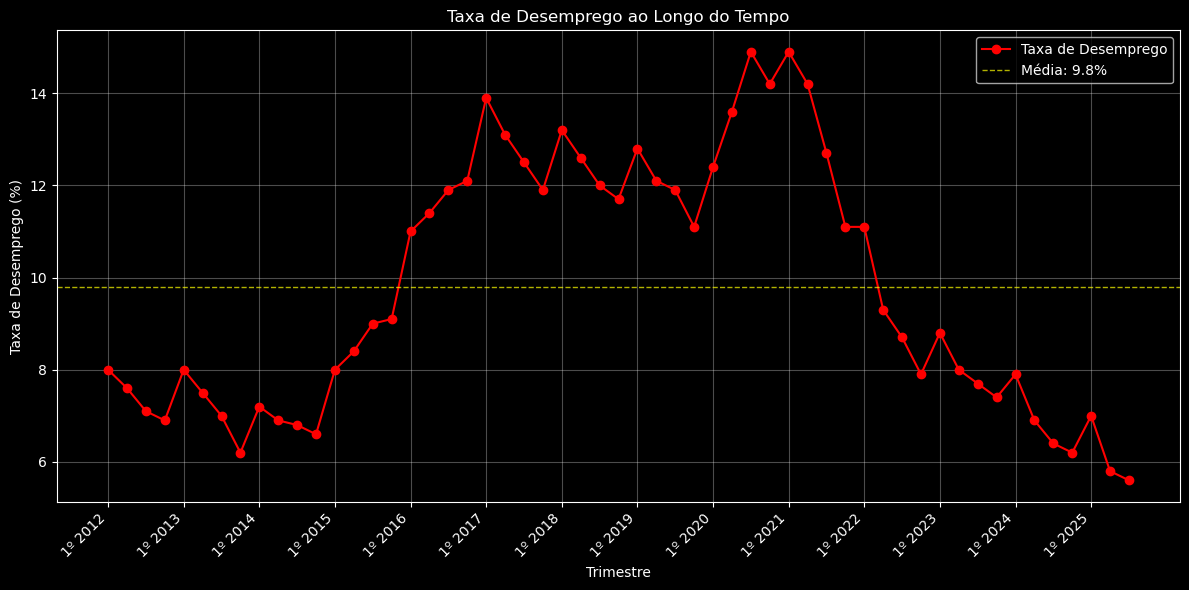

In [ ]:
# Gráficos
import matplotlib.pyplot as plt
# Desemprego ao longo do tempo
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
plt.plot(df_completo['Trimestre'], df_completo['Taxa de Desemprego'], marker='o', label='Taxa de Desemprego', markersize=6, color='red')
n = len(df_completo)
step = 4  
plt.xticks(range(0, n, step), 
           df_completo['Trimestre'][::step], 
           rotation=45, ha='right')
# Linha mostrando a média
media = df_completo['Taxa de Desemprego'].mean()
plt.axhline(y=media, color='yellow', linestyle='--', linewidth=1, alpha=0.7, label=f'Média: {media:.1f}%')
plt.title('Taxa de Desemprego ao Longo do Tempo')
plt.xlabel('Trimestre')
plt.ylabel('Taxa de Desemprego (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_path = 'taxa_desemprego.png'
plt.savefig(save_path, dpi=300)
plt.show()

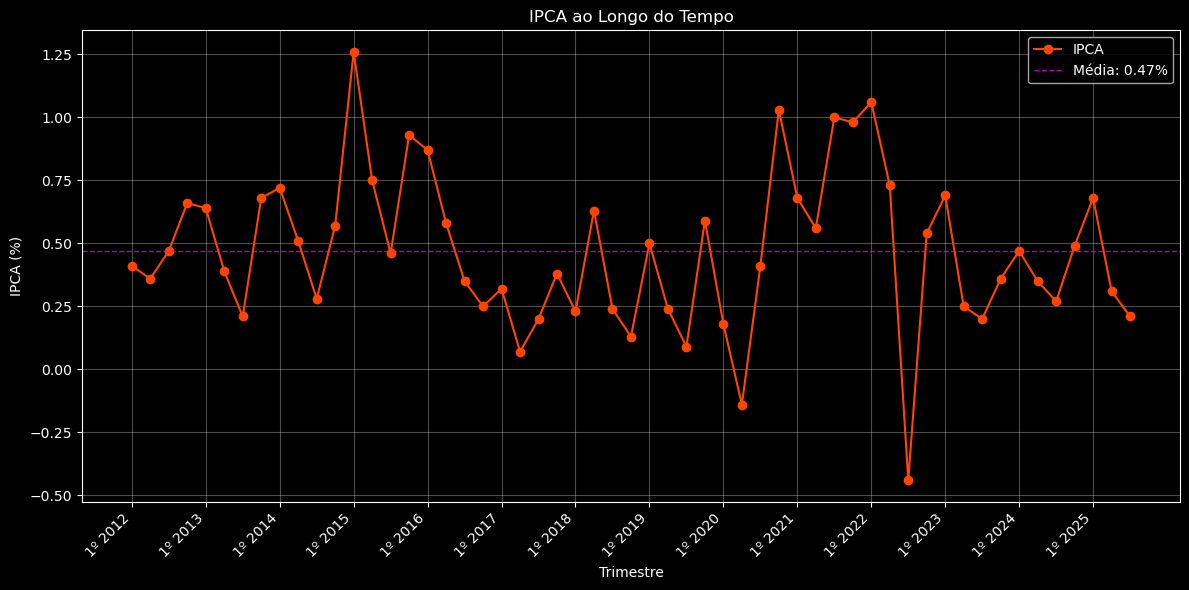

In [ ]:
# IPCA ao longo do tempo
plt.rcdefaults()
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
plt.plot(df_completo['Trimestre'], df_completo['IPCA'], marker='o', label='IPCA', markersize=6, color='orangered')
n = len(df_completo)
step = 4  
plt.xticks(range(0, n, step), 
           df_completo['Trimestre'][::step], 
           rotation=45, ha='right')
# Linha mostrando a média
media_ipca = df_completo['IPCA'].mean()
plt.axhline(y=media_ipca, color='magenta', linestyle='--', linewidth=1, alpha=0.7, label=f'Média: {media_ipca:.2f}%')
plt.title('IPCA ao Longo do Tempo')
plt.xlabel('Trimestre')
plt.ylabel('IPCA (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_path = 'ipca.png'
plt.savefig(save_path, dpi=300)
plt.show()

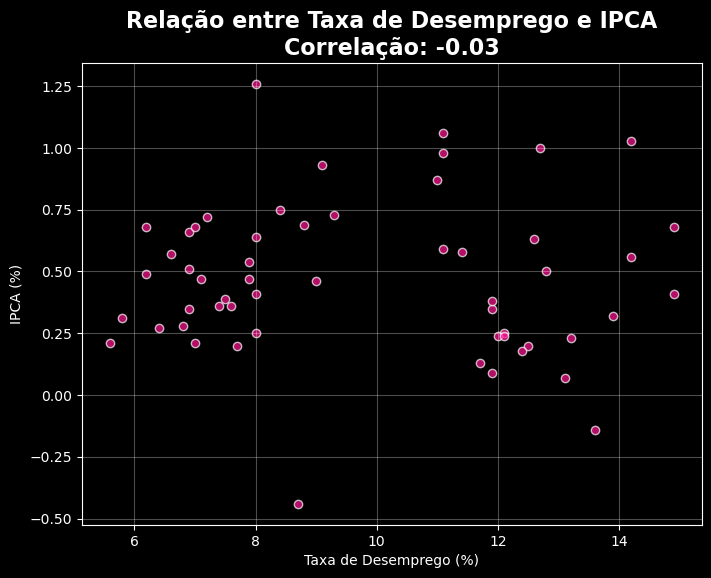

In [59]:
# Scatter plot para ver relação entre desemprego e inflação
plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
plt.scatter(df_completo['Taxa de Desemprego'], df_completo['IPCA'], color='deeppink', edgecolor='white', alpha=0.7)
plt.title(f'Relação entre Taxa de Desemprego e IPCA\nCorrelação: {correlacao:.2f}', 
          fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Desemprego (%)')
plt.ylabel('IPCA (%)')
plt.grid(alpha=0.3)
save_path = 'desemprego_vs_ipca.png'
plt.savefig(save_path, dpi=300)
plt.show()

In [62]:
df_completo.to_csv('desemprego_vs_inflacao_completo.csv', index=False, encoding='utf-8-sig')
df_ipca_limpo.to_csv('ipca_mensal.csv', index=False, encoding='utf-8-sig')
df_limpo.to_csv('desemprego_trimestral.csv', index=False, encoding='utf-8-sig')